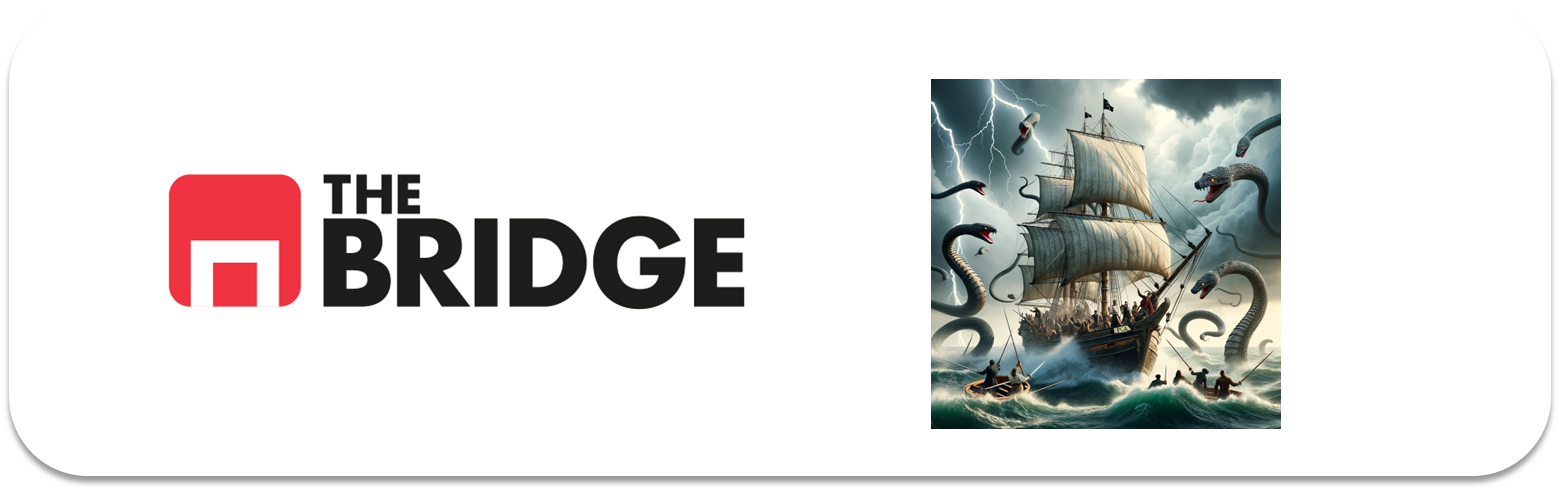

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bvt

from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif, 
    mutual_info_classif, SelectFromModel, RFE, SequentialFeatureSelector
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import recall_score, classification_report, confusion_matrix

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [4]:
df = pd.read_csv('data/credit_npo.csv').drop(columns=['Unnamed: 0'], errors='ignore')

In [6]:
#LIMPIEZA Y PREPROCESAMIENTO DE FILAS Y CATEGÓRICAS
df = df.dropna()

#Convertimos variables "NumberOf..." conflictivas a categóricas de 2 o 3 niveles 
def bin_number_of_times(val):
    if val == 0: return '0_times'
    elif val == 1: return '1_time'
    else: return '2_or_more'

cols_to_bin = [
    'NumberOfTime30-59DaysPastDueNotWorse', 
    'NumberOfTime60-89DaysPastDueNotWorse', 
    'NumberOfTimes90DaysLate'
]

for col in cols_to_bin:
    if col in df.columns:
        df[col] = df[col].apply(bin_number_of_times)

#Separamos features y target
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

#Separación Train/Test 
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Identificamos tipos de columnas tras la transformación
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()

#Preparamos un dataset codificado (one-hot encoding para las categóricas y escalado para numéricas)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

X_train = pd.DataFrame(preprocessor.fit_transform(X_train_raw), columns=preprocessor.get_feature_names_out())
X_test = pd.DataFrame(preprocessor.transform(X_test_raw), columns=preprocessor.get_feature_names_out())

print(f"Dataset listo. Dimensiones: {X_train.shape}")

# Dict para almacenar
listas_features = {}



Dataset listo. Dimensiones: (9452, 7)


C:\Users\lolar\AppData\Local\Temp\ipykernel_2796\803466248.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()


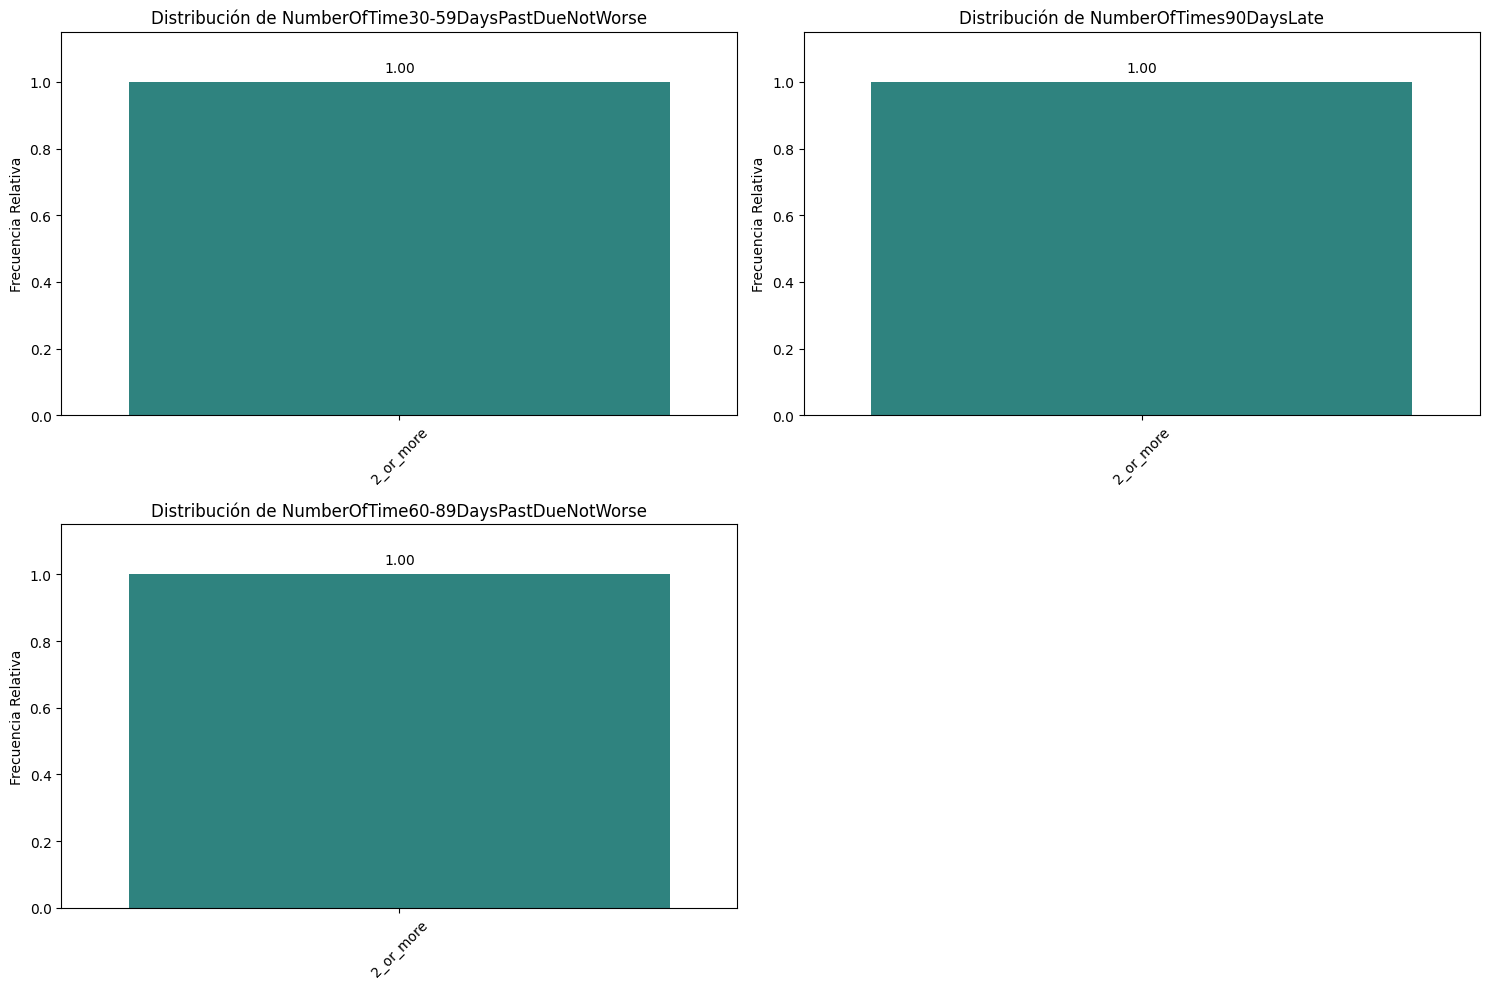

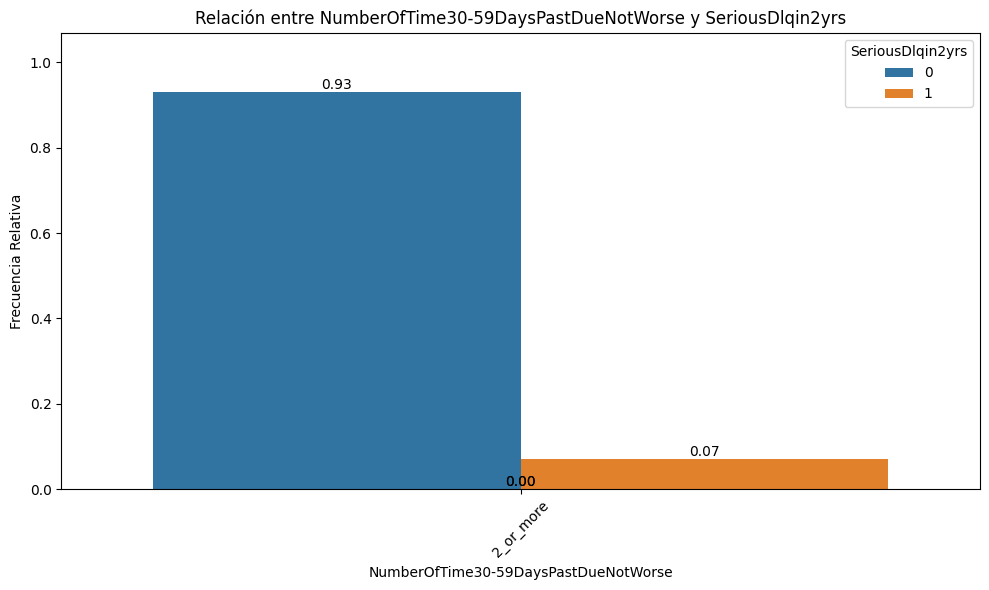

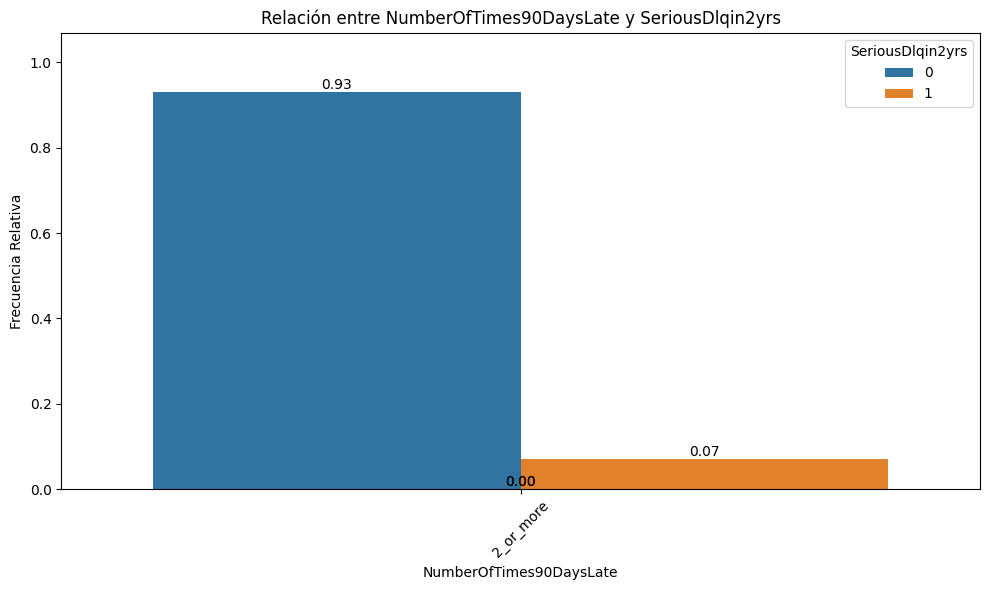

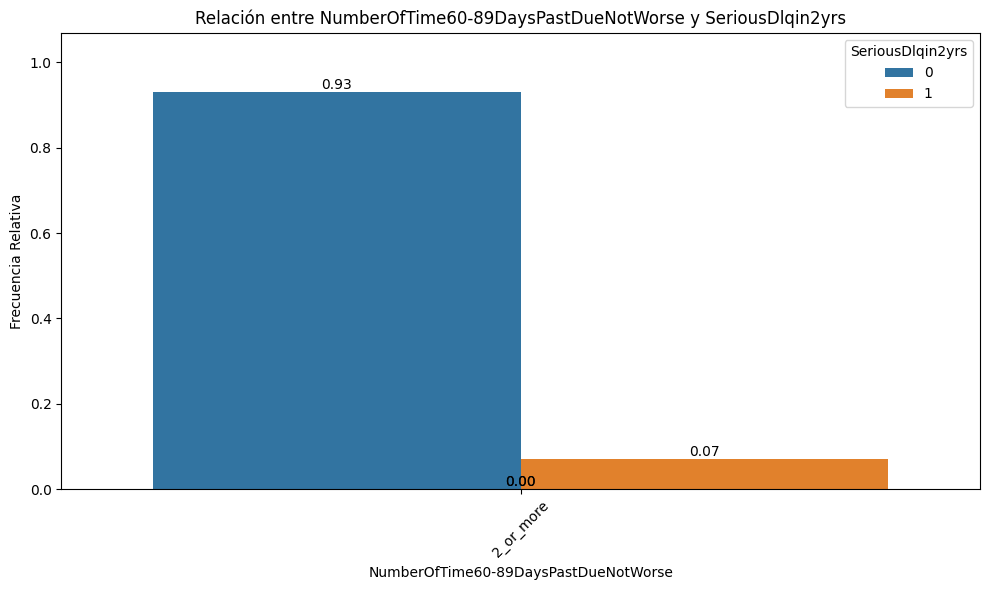

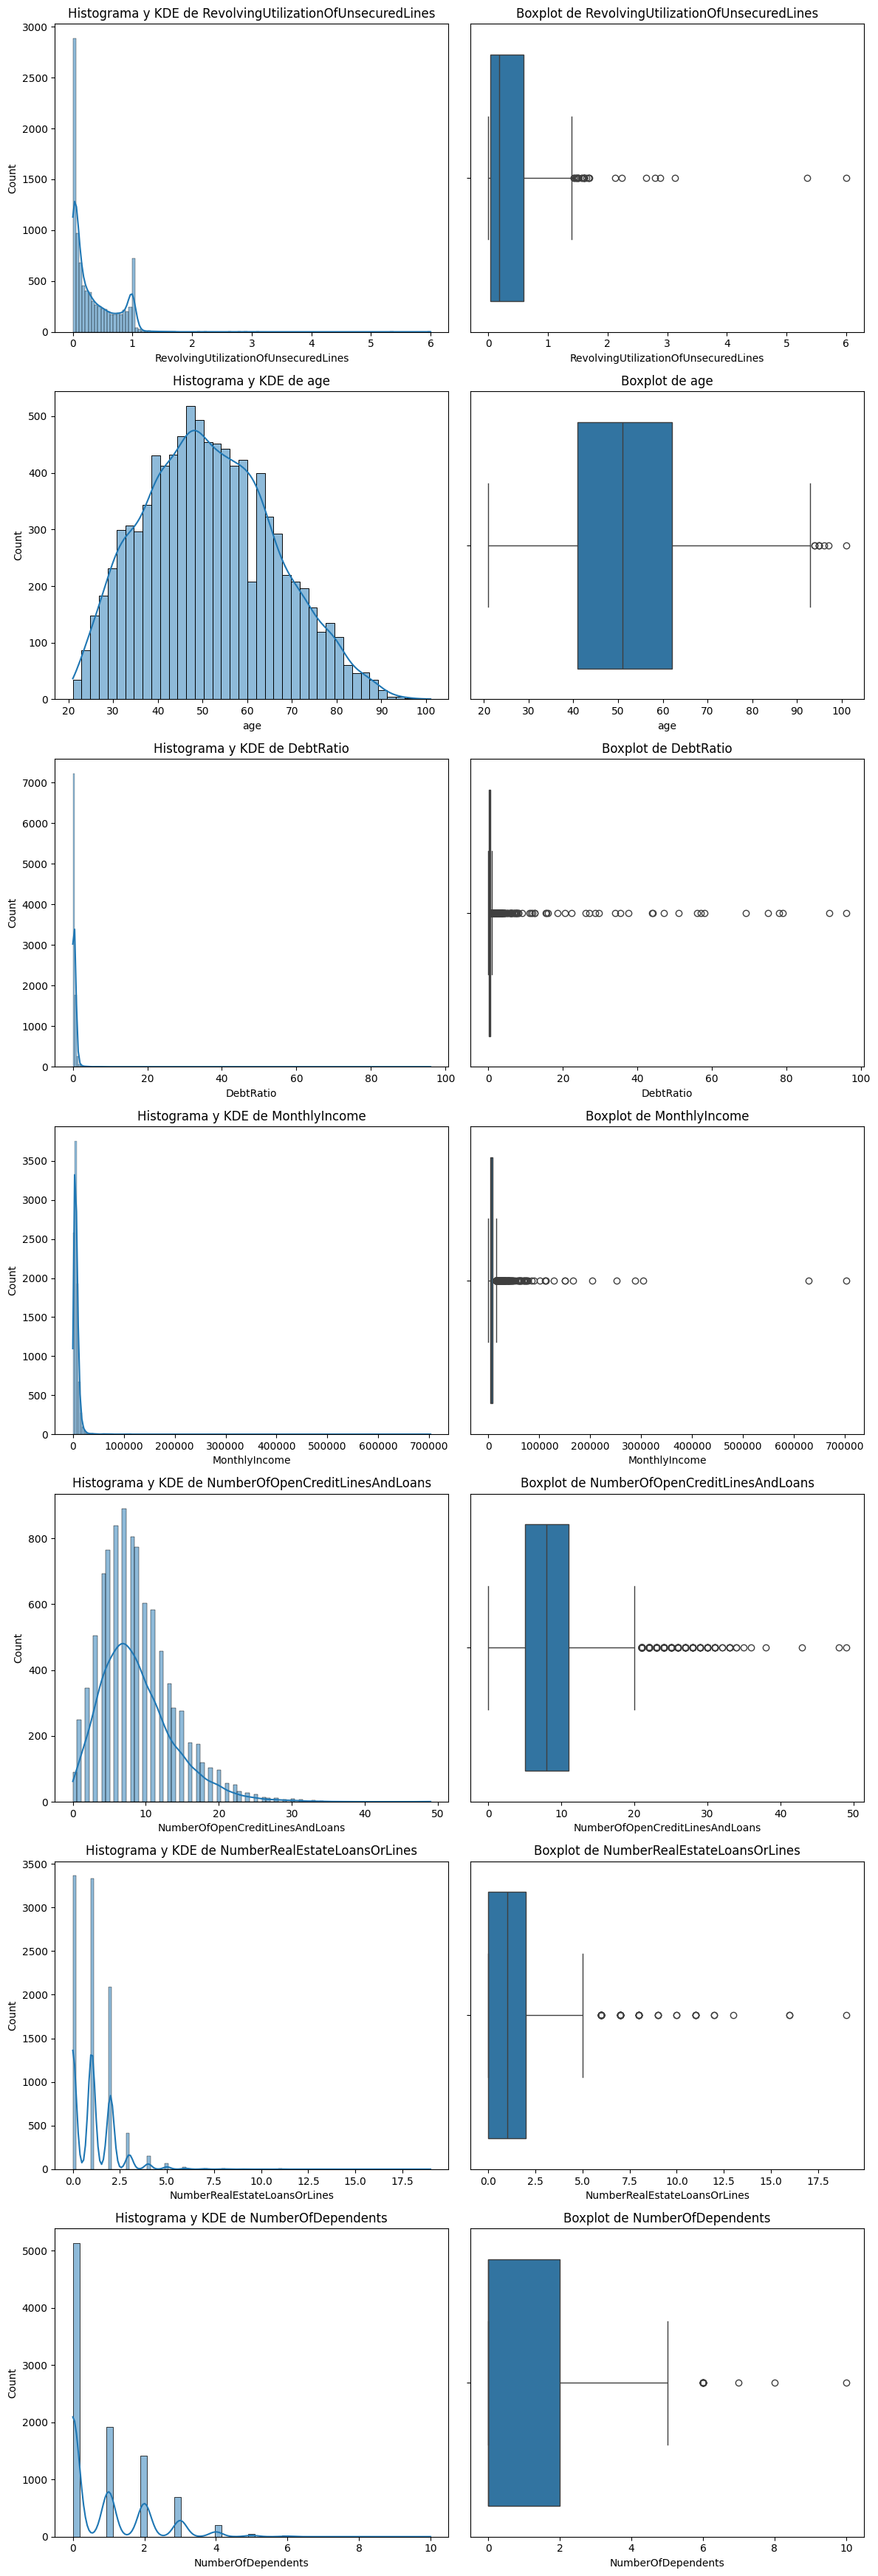


'Filtro_Manual' guardado con éxito.


In [10]:
#MINI-EDA & SELECCIÓN DE FEATURES
 
#Visualizamos la distribución de las variables categóricas
bvt.pinta_distribucion_categoricas(
    df=X_train_raw, 
    columnas_categoricas=cat_cols, 
    relativa=True, 
    mostrar_valores=True
)

#Analizamos cómo se comportan frente a la variable objetivo
for col in cat_cols:
    bvt.plot_categorical_relationship(
        df=pd.concat([X_train_raw, y_train], axis=1), 
        cat_col1=col, 
        cat_col2='SeriousDlqin2yrs', 
        relative_freq=True, 
        show_values=True
    )

#Inspeccionamos las variables numéricas en busca de asimetrías y outliers
bvt.plot_combined_graphs(df=X_train_raw, columns=num_cols)


#Filtrado
#Filtro por varianza
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_train)
features_deseadas = X_train.columns[selector_var.get_support()].tolist()

#Correlación directa con el target
corr_with_target = X_train[features_deseadas].apply(lambda x: x.corr(y_train)).abs()
corr_with_target = corr_with_target.sort_values(ascending=False)

#Guardamos el primer set de primera división
listas_features['Filtro_Manual'] = corr_with_target.head(6).index.tolist()
print("\n'Filtro_Manual' guardado con éxito.")

In [11]:
#COMPARATIVA DE MODELOS (Matriz 6x3 = 18 experimentos)
modelos = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=6),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=13) # Ajuste por desbalanceo de clases
}

resultados_matriz = []

for nom_lista, features in listas_features.items():
    X_train_sub = X_train[features]
    for nom_modelo, modelo in modelos.items():
        scores = cross_val_score(modelo, X_train_sub, y_train, cv=5, scoring='recall', n_jobs=-1)
        mean_recall = scores.mean()
        
        resultados_matriz.append({
            'Lista_Features': nom_lista,
            'Modelo': nom_modelo,
            'Mean_Recall': mean_recall
        })

df_resultados = pd.DataFrame(resultados_matriz)
print("\n=== MATRIZ DE RESULTADOS (ORDENADA POR RECALL) ===")
print(df_resultados.sort_values(by='Mean_Recall', ascending=False).to_string(index=False))

#Selección automática del mejor
mejor_caso = df_resultados.sort_values(by='Mean_Recall', ascending=False).iloc[0]
mejor_modelo_nombre = mejor_caso['Modelo']
mejor_lista_nombre = mejor_caso['Lista_Features']
features_finales = listas_features[mejor_lista_nombre]

print(f"\n Ganador: Modelo '{mejor_modelo_nombre}' usando la lista '{mejor_lista_nombre}'")



=== MATRIZ DE RESULTADOS (ORDENADA POR RECALL) ===
Lista_Features             Modelo  Mean_Recall
 Filtro_Manual LogisticRegression     0.730428
 Filtro_Manual       RandomForest     0.698770
 Filtro_Manual            XGBoost     0.329859

 Ganador: Modelo 'LogisticRegression' usando la lista 'Filtro_Manual'


In [12]:
#OPTIMIZACIÓN DE HIPERPARÁMETROS Y EVALUACIÓN FINAL
X_train_final = X_train[features_finales]
X_test_final = X_test[features_finales]

#Instanciamos de nuevo el modelo ganador para el GridSearch
if mejor_modelo_nombre == 'LogisticRegression':
    param_grid = {'C': [0.01, 0.1, 1, 10]}
    base_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
elif mejor_modelo_nombre == 'RandomForest':
    param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [4, 6, 8]}
    base_model = RandomForestClassifier(random_state=42, class_weight='balanced')
else:
    param_grid = {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]}
    base_model = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=13)

grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train_final, y_train)

best_model = grid_search.best_estimator_
print(f"\nMejores hiperparámetros: {grid_search.best_params_}")

#Evaluación final en Test
y_pred = best_model.predict(X_test_final)

print("\nReporte de clasificación en test:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión")
print(confusion_matrix(y_test, y_pred))


Mejores hiperparámetros: {'C': 0.01}

Reporte de clasificación en test:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      2198
           1       0.17      0.73      0.28       166

    accuracy                           0.74      2364
   macro avg       0.57      0.73      0.56      2364
weighted avg       0.92      0.74      0.80      2364

Matriz de confusión
[[1618  580]
 [  45  121]]


### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

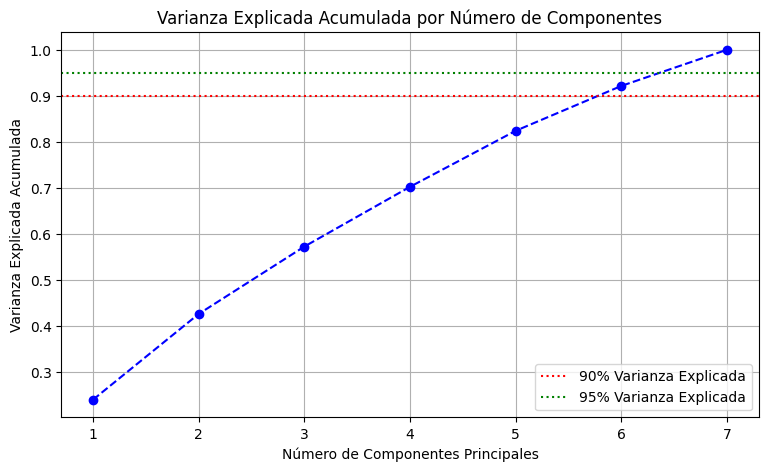

Número de componentes necesarias para explicar el 90% de la varianza: 6
Transformando datasets con n_components = 6

Entrenando el modelo ganador con los datos transformados por PCA

Reporte de clasificación en test(CON PCA)
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      2198
           1       0.17      0.73      0.28       166

    accuracy                           0.74      2364
   macro avg       0.57      0.73      0.56      2364
weighted avg       0.92      0.74      0.80      2364

Matriz de confusión (CON PCA)
[[1619  579]
 [  45  121]]


In [14]:
#EXTRA: REDUCCIÓN DE DIMENSIONALIDAD CON PCA
#Ajustamos un PCA con todas las componentes posibles para evaluar la varianza
from sklearn.decomposition import PCA


pca_completo = PCA(random_state=42)
pca_completo.fit(X_train)

# alculamos la varianza explicada acumulada
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

# Visualización de la varianza explicada
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Varianza Explicada')
plt.axhline(y=0.95, color='g', linestyle=':', label='95% Varianza Explicada')
plt.title('Varianza Explicada Acumulada por Número de Componentes')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend(loc='best')
plt.grid(True)
plt.show()

#Elegir el número de componentes
#Buscamos cuántas componentes se necesitan para cubrir, por ejemplo, el 90% o 95% de la varianza
n_componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Número de componentes necesarias para explicar el 90% de la varianza: {n_componentes_90}")

#Aplicamos el PCA definitivo con el número óptimo elegido
n_comp_elegido = min(6, n_componentes_90)
print(f"Transformando datasets con n_components = {n_comp_elegido}")

pca_final = PCA(n_components=n_comp_elegido, random_state=42)
X_train_pca = pca_final.fit_transform(X_train)
X_test_pca = pca_final.transform(X_test)

#Entrenar el tipo de modelo ganador con los hiperparámetros optimizados
from sklearn.base import clone
modelo_pca = clone(best_model) 

print(f"\nEntrenando el modelo ganador con los datos transformados por PCA")
modelo_pca.fit(X_train_pca, y_train)

#Evaluación
y_pred_pca = modelo_pca.predict(X_test_pca)

print("\nReporte de clasificación en test(CON PCA)")
print(classification_report(y_test, y_pred_pca))

print("Matriz de confusión (CON PCA)")
print(confusion_matrix(y_test, y_pred_pca))